## Enderscopy stage demo
### shows how to create a virtual enderscope stage

In [1]:
# Needed to import from the enderscope library

import os

os.chdir("..")

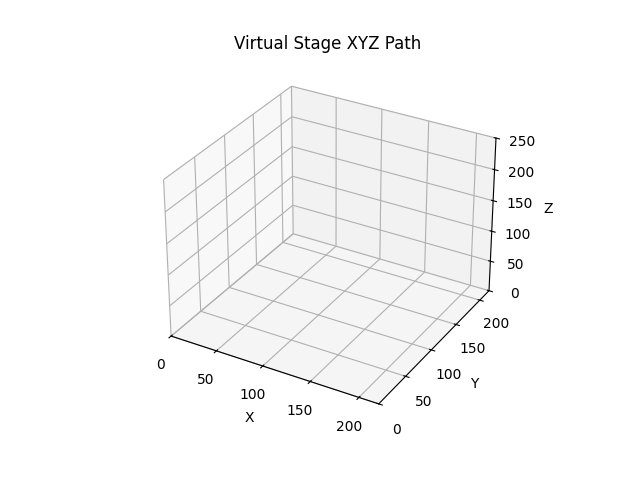

In [2]:
import time
from enderscope.serial import Stage

# connect to a virtual enderscope and create a stage object
%matplotlib widget
s = Stage("virtual", 115200)

## Grab xyz example coordinates and push them as history

In [3]:
from urllib.request import urlopen


def get_xyz_points(url="https://people.math.sc.edu/Burkardt/data/xyz/helix_201.xyz"):
    """
    Download an .xyz text file and return a list of (x, y, z) float tuples.
    Lines that are empty or nonnumeric are ignored.
    """
    points = []

    with urlopen(url) as response:
        for raw_line in response.readlines():
            line = raw_line.decode("utf-8").strip()
            if not line:
                continue  # skip blanks

            parts = line.split()
            if len(parts) < 3:
                continue  # skip malformed lines

            try:
                x, y, z = map(float, parts[:3])
            except ValueError:
                continue  # skip header or bad rows

            points.append((x, y, z))

    return points


points = get_xyz_points()

In [4]:
import numpy as np

arr = np.array(points, dtype=float)

# scale
scaled = arr * 20.0

# offset (translate)
offset = scaled + np.array([150, 150.0, 80])
s.set_history(offset)
s.home()